# Synthetic fBM Dataset Generation and Classification

Generates a synthetic particle tracking dataset using fractional Brownian motion (fBM) with three anomalous diffusion exponents (α = 0.5, 1.0, 1.5). The dataset mirrors the class imbalance and trajectory length distribution of the cytoplasmic dataset. A classifier is then trained and evaluated on this controlled benchmark.

In [1]:
import os
import subprocess

repo_root = subprocess.check_output(["git", "rev-parse", "--show-toplevel"]).decode().strip()
os.chdir(repo_root)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from andi_datasets.models_theory import models_theory

from trajan.data import TracksDataFrame
from trajan.trainer import evaluate, run
from trajan.visualization import plot_classification_report, plot_confusion_matrix

## Reference Dataset

Load the cytoplasmic dataset to extract the structural statistics (number of recordings, tracks per recording, average trajectory length per class) that the synthetic dataset will mirror.

In [ ]:
tracks_path = os.path.join("data", "cytoplasmic", "tracks.csv")

data = pd.read_csv(tracks_path, skiprows=1)
data = TracksDataFrame(data, frame_rate=10)

data_description = data.describe_tracks()

particle_types: ['endosome', 'golgi', 'postgolgi']
frame_rate: 10

endosome:
  n_recordings: 20
  recording_ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  n_tracks: 339
  avg_track_len: 130.65

golgi:
  n_recordings: 7
  recording_ids: [20, 21, 22, 23, 24, 25, 26]
  n_tracks: 103
  avg_track_len: 142.37

postgolgi:
  n_recordings: 11
  recording_ids: [27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
  n_tracks: 131
  avg_track_len: 131.94


## Synthetic Dataset Generation

fBM trajectories are generated for each class using `andi_datasets`. Trajectory lengths are sampled from a normal distribution centred at the reference average length (std = 20 frames). The anomalous exponent α is the only parameter assigned manually; all structural parameters come directly from `data_description`.

In [4]:
rng = np.random.default_rng(42)
models = models_theory()._twoD()

# Alpha exponent assigned to each particle type (in the order returned by describe_tracks)
alpha_map = dict(zip(data_description["particle_types"], [0.5, 1.0, 1.5]))

class_configs = []
for ptype in data_description["particle_types"]:
    stats = data_description[ptype]
    alpha = alpha_map[ptype]
    class_configs.append({
        "type": f"fbm_a_{alpha}",
        "alpha": alpha,
        "n_recordings": stats["n_recordings"],
        "n_tracks": round(stats["n_tracks"] / stats["n_recordings"]),
        "avg_length": stats["avg_track_len"],
    })

rows = []
set_offset = 0

for cfg_class in class_configs:
    alpha = cfg_class["alpha"]
    for rec_idx in range(cfg_class["n_recordings"]):
        set_id = set_offset + rec_idx
        for track_idx in range(cfg_class["n_tracks"]):
            T = max(30, int(rng.normal(cfg_class["avg_length"], 20)))
            traj = models.fbm(T=T, alpha=alpha).reshape(2, -1).T
            for t in range(T):
                rows.append({
                    "x": float(traj[t, 0]),
                    "y": float(traj[t, 1]),
                    "frame": t,
                    "label": track_idx,
                    "set": set_id,
                    "type": cfg_class["type"],
                })
    set_offset += cfg_class["n_recordings"]

sim_data = TracksDataFrame(pd.DataFrame(rows), frame_rate=10)
fbm_dataset_description = sim_data.describe_tracks()

particle_types: ['fbm_a_0.5', 'fbm_a_1.0', 'fbm_a_1.5']
frame_rate: 10

fbm_a_0.5:
  n_recordings: 20
  recording_ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  n_tracks: 340
  avg_track_len: 129.96

fbm_a_1.0:
  n_recordings: 7
  recording_ids: [20, 21, 22, 23, 24, 25, 26]
  n_tracks: 105
  avg_track_len: 140.75

fbm_a_1.5:
  n_recordings: 11
  recording_ids: [27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
  n_tracks: 132
  avg_track_len: 131.18


## Trajectory Visualization

Plot sample trajectories from one recording per class to visually confirm the three diffusion regimes: confined (α = 0.5), Brownian (α = 1.0), and directed (α = 1.5).

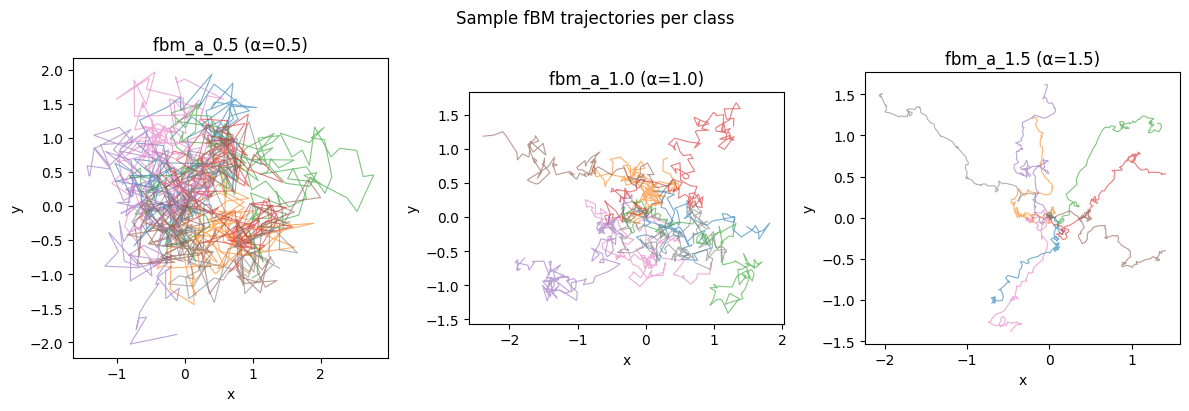

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, cfg_class in zip(axes, class_configs):
    ptype = cfg_class["type"]
    type_data = sim_data[sim_data["type"] == ptype]
    first_set = type_data["set"].iloc[0]
    recording = type_data[type_data["set"] == first_set]
    for label_id in recording["label"].unique()[:8]:
        track = recording[recording["label"] == label_id]
        ax.plot(track["x"], track["y"], alpha=0.6, lw=0.8)
    ax.set_title(f"{ptype} (α={cfg_class['alpha']})")
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
plt.suptitle("Sample fBM trajectories per class")
plt.tight_layout()

## Save Dataset

Write the synthetic dataset to CSV in the same format as the cytoplasmic data so it can be used as a drop-in replacement via the config.

In [ ]:
save_path = os.path.join("data", "simulated", "fbm_tracks.csv")
os.makedirs(os.path.dirname(save_path), exist_ok=True)
with open(save_path, "w") as f:
    f.write("# frame_rate=10, source=simulated_fbm\n")
sim_data.to_csv(save_path, mode="a", index=False)
print(f"Saved {len(sim_data)} detections to {save_path}")

Saved 76280 detections to data/simulated_data/tracks.csv


## Training

Run the full training pipeline on the simulated dataset. The config is defined inline here; for scripted runs use `configs/base.yaml` with `data.path` pointing to the simulated CSV.

In [ ]:
config = {
    "seed": 42,
    "output_dir": "runs",
    "data": {
        "path": "data/simulated/fbm_tracks.csv",
        "frame_rate": 10,
        "test_size": 0.25,
    },
    "graph": {
        "max_frame_distance": 3,
        "Dt": 80,
    },
    "model": {
        "encoder_dimension": 96,
        "num_blocks": 4,
        "num_classes": 3,
    },
    "training": {
        "lr": 1e-4,
        "weight_decay": 5e-4,
        "batch_size": 16,
        "val_batch_size": 256,
        "num_epochs": 10,
        "sample_balanced": True,
        "weighted_loss": False,
        "dataset_size_multiplier": "auto",
    },
}

best_val_loss, run_dir, best_model, train_loader, val_loader, display_labels = run(config)

## Evaluation

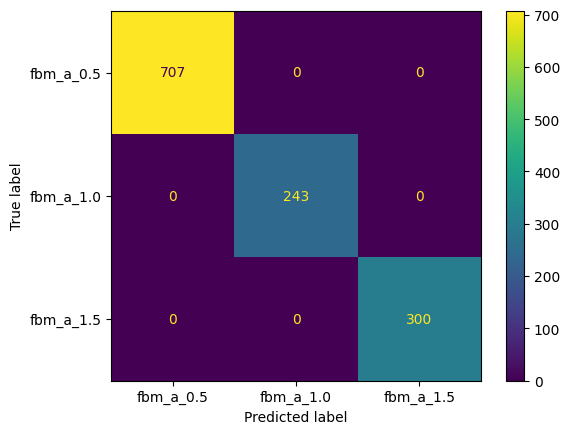

In [ ]:
report_df, cm_df = evaluate(best_model, val_loader, display_labels)

fig = plot_confusion_matrix(cm_df, display_labels)
plt.show(fig)

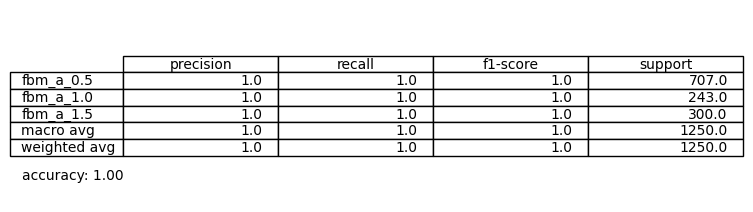

In [15]:
fig = plot_classification_report(report_df)
plt.show(fig)
